<a href="https://colab.research.google.com/github/thomaslu678/Praxis-Lab-25-26/blob/main/clean/14_VIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTE: Requires calculations_df

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta
import scipy.stats as stats
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Point
import requests
import random
import os
import math
import copy
import sys
import gc

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Generate patches for park #2

In [4]:
point_row_col_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/2_Clipped.csv')

In [5]:
point_row_col_df

,row_index,col_index,point_id
0,17,1,0
1,18,1,1
2,19,1,2
3,20,1,3
4,21,1,4
...,...,...,...
4623,11,208,4623
4624,12,208,4624
4625,13,208,4625
4626,14,208,4626


In [6]:
point_row_col_df['point_id'] = point_row_col_df['point_id'] + 1

In [7]:
point_row_col_df

,row_index,col_index,point_id
0,17,1,1
1,18,1,2
2,19,1,3
3,20,1,4
4,21,1,5
...,...,...,...
4623,11,208,4624
4624,12,208,4625
4625,13,208,4626
4626,14,208,4627


In [8]:
lookup = {(r,c):pid for r,c,pid in zip(point_row_col_df.row_index, point_row_col_df.col_index, point_row_col_df.point_id)}

In [9]:
# Expect size to be an odd integer
def get_patches(df, size):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [10]:
PATCH_SIZE = 5

In [11]:
patches_2 = get_patches(point_row_col_df, PATCH_SIZE)
print(patches_2.shape)  # (#patches,5,5)

(3587, 5, 5)


# Generate patches for park #0 (Green Loop)

In [ ]:
point_row_col_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_Clipped.csv')

In [ ]:
point_row_col_df

,row_index,col_index,point_id
0,92,1,0
1,93,1,1
2,94,1,2
3,95,1,3
4,96,1,4
...,...,...,...
6936,23,72,6936
6937,24,72,6937
6938,25,72,6938
6939,26,72,6939


In [ ]:
lookup = {(r,c):pid for r,c,pid in zip(point_row_col_df.row_index, point_row_col_df.col_index, point_row_col_df.point_id)}

In [ ]:
# Expect size to be an odd integer
def get_patches(df, size):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [ ]:
PATCH_SIZE = 5

In [ ]:
patches_0 = get_patches(point_row_col_df, PATCH_SIZE)
print(patches_0.shape)  # (#patches,5,5)

(5629, 5, 5)


# Load datasets to populate patches

## Train dataset

In [12]:
train_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/landsat_city_points_minimal.csv')

In [13]:
train_df = train_df_load.copy()

In [14]:
train_df['time'] = pd.to_datetime(train_df['time'], format='%Y-%m-%d %H:%M:%S')

In [15]:
train_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,2505,L4,1988-12-24 01:43:00,0.195835,0.210300,0.213737,0.196330,0.176255,272.622947
1,2527,L4,1988-12-24 01:43:00,0.202545,0.210300,0.213737,0.172900,0.148782,272.622947
2,2528,L4,1988-12-24 01:43:00,0.202545,0.204415,0.199850,0.163550,0.135087,272.622947
3,2550,L4,1988-12-24 01:43:00,0.195835,0.204415,0.192865,0.168225,0.141935,272.718652
4,2551,L4,1988-12-24 01:43:00,0.195835,0.210300,0.213737,0.177575,0.148782,272.718652
...,...,...,...,...,...,...,...,...,...
2646549,4618,L9,2026-01-31 02:11:17,0.065045,0.089052,0.131595,0.151615,0.115177,274.547293
2646550,4619,L9,2026-01-31 02:11:17,0.069005,0.108495,0.204250,0.236617,0.178015,274.506276
2646551,4620,L9,2026-01-31 02:11:17,0.117405,0.163055,0.224133,0.170673,0.129010,274.725030
2646552,4627,L9,2026-01-31 02:11:17,0.060067,0.080857,0.111052,0.118175,0.096917,274.588309


## Predict dataset

In [ ]:
predict_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_landsat.csv')

In [ ]:
predict_df = predict_df_load.copy()

In [ ]:
predict_df['time'] = pd.to_datetime(predict_df['time'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
predict_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,240,L4,1982-11-19 17:36:28,0.111658,0.120347,0.110805,0.079702,0.056575,280.665548
1,288,L4,1982-11-19 17:36:28,0.174220,0.207632,0.206780,0.206697,0.182030,281.209014
2,290,L4,1982-11-19 17:36:28,0.139927,0.167015,0.172570,0.156812,0.135830,280.665548
3,311,L4,1982-11-19 17:36:28,0.186622,0.224985,0.227268,0.197622,0.175430,280.665548
4,350,L4,1982-11-19 17:36:28,0.143062,0.178620,0.193112,0.143228,0.116002,281.752479
...,...,...,...,...,...,...,...,...,...
5628727,6936,L9,2026-01-12 18:08:31,0.024922,0.035647,0.052642,0.053825,0.038205,274.424244
5628728,6937,L9,2026-01-12 18:08:31,0.031055,0.047610,0.057125,0.040460,0.035290,275.466740
5628729,6938,L9,2026-01-12 18:08:31,0.039800,0.072580,0.071508,0.065155,0.058665,276.522908
5628730,6939,L9,2026-01-12 18:08:31,0.059682,0.104177,0.121502,0.164237,0.117130,277.271455


In [ ]:
print(predict_df['point_id'].min(), predict_df['point_id'].max())

0 6940


# Populate patches

### Populate definitions + method

In [16]:
features = ['Blue', 'Red', 'SWIR1', 'SWIR2']
target_col = 'LST_K'

In [17]:
def populate_patches(input_df, input_patches):

    # -------------------------
    # 1. Pivot
    # -------------------------
    df_pivot = input_df.pivot(
        index='time',
        columns='point_id',
        values=features + [target_col]
    ).sort_index()

    times = df_pivot.index.values
    point_ids = df_pivot.columns.levels[1].values

    # -------------------------
    # 2. Build feature tensor CORRECTLY
    # -------------------------
    # stack each feature explicitly to preserve alignment
    X = np.stack(
        [df_pivot[feat].values for feat in features],
        axis=-1
    )
    # shape: (T, P, F)

    y = df_pivot[target_col].values  # (T, P)

    # -------------------------
    # 3. point_id → index
    # -------------------------
    point_id_to_idx = {pid: i for i, pid in enumerate(point_ids)}

    all_patches_cubes = []
    all_patches_targets = []
    all_patches_times = []

    for patch in input_patches:
        patch = np.array(patch)
        flat_ids = patch.flatten()

        # map indices safely
        if not all(pid in point_id_to_idx for pid in flat_ids):
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        idxs = np.array([point_id_to_idx[pid] for pid in flat_ids])
        center_idx = point_id_to_idx[patch[2, 2]]

        # extract all times at once
        patch_data = X[:, idxs, :]   # (T, 25, F)

        # validity mask
        valid_mask = ~np.isnan(patch_data).any(axis=(1, 2))

        if not valid_mask.any():
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        valid_patch_data = patch_data[valid_mask]
        valid_targets = y[valid_mask, center_idx]
        valid_times = times[valid_mask]

        # reshape to cubes
        cubes = valid_patch_data.reshape(-1, 5, 5, len(features))
        cubes = np.transpose(cubes, (0, 3, 1, 2))  # (Tv, F, 5, 5)

        all_patches_cubes.append(cubes)
        all_patches_targets.append(valid_targets)
        all_patches_times.append(valid_times)

    return all_patches_cubes, all_patches_targets, all_patches_times

### Populate #0 patches

In [ ]:
cubes_0, targets_0, times_0 = populate_patches(predict_df, patches_0)

NameError: name 'predict_df' is not defined

In [ ]:
cubes_0[0][0]

In [ ]:
targets_0[0][0]

In [ ]:
times_0[0][0]

NameError: name 'times_0' is not defined

In [ ]:
min_len = min(len(patch) for patch in times_0)
print(min_len)

### Populate #2 patches

In [18]:
cubes_2, targets_2, times_2 = populate_patches(train_df, patches_2)

In [19]:
cubes_2[0][0]

array([[[0.0883925, 0.0883925, 0.0900425, 0.091665 , 0.0867425],
        [0.0883925, 0.07357  , 0.08347  , 0.090015 , 0.0817925],
        [0.0834425, 0.0685925, 0.0817925, 0.0998325, 0.0801425],
        [0.0834425, 0.073515 , 0.071865 , 0.0866875, 0.08831  ],
        [0.076815 , 0.0652375, 0.0685375, 0.0833875, 0.098155 ]],

       [[0.1314025, 0.12824  , 0.13451  , 0.13451  , 0.12824  ],
        [0.1251325, 0.103215 , 0.1188625, 0.1314025, 0.1219975],
        [0.12824  , 0.096945 , 0.1157275, 0.1407525, 0.1251325],
        [0.1251325, 0.10635  , 0.103215 , 0.12824  , 0.1219975],
        [0.103215 , 0.0780525, 0.09062  , 0.1188625, 0.14386  ]],

       [[0.14287  , 0.1558225, 0.158435 , 0.1532375, 0.1454825],
        [0.14804  , 0.1247475, 0.1428975, 0.158435 , 0.1428975],
        [0.1532375, 0.1247475, 0.1609925, 0.199795 , 0.16619  ],
        [0.15585  , 0.1351425, 0.1195775, 0.1609925, 0.173945 ],
        [0.1454825, 0.140285 , 0.1377   , 0.1894825, 0.18687  ]],

       [[0.12747  ,

In [20]:
targets_2[0][0]

np.float64(317.65877888)

In [21]:
times_2[0][0]

np.datetime64('1984-07-30T01:40:17.000000000')

In [22]:
min_len = min(len(patch) for patch in times_2)
print(min_len)

321


In [23]:
len(cubes_2)

3587

# Compute time embeddings

## Methods and definitions

In [24]:
def transform_times(transformed, times_0):
    for lst in times_0:
        new_lst = []
        # if not lst:
        #     transformed.append(new_lst)
        #     continue

        # Convert entire list at once (much faster)
        t = pd.to_datetime(lst)

        # Extract components (vectorized)
        year = t.year.values
        month = t.month.values
        day_of_year = t.dayofyear.values

        # Seasonality (vectorized)
        seasonality = np.sin((2 * np.pi) * day_of_year / 365)

        # Differences
        diff_prev = np.diff(t.values).astype('timedelta64[D]').astype(int)
        diff_prev = np.insert(diff_prev, 0, 0)  # first element = 0

        diff_first = (t - t[0]).days.values

        # Stack into feature matrix
        features = np.column_stack([
            year,
            month,
            day_of_year,
            seasonality,
            diff_prev,
            diff_first
        ])

        transformed.append(features.tolist())

## Time embeddings of 0

In [ ]:
time_embeddings_0 = []

In [ ]:
transform_times(time_embeddings_0, times_0)

In [ ]:
len(time_embeddings_0)

5629

## Time embeddings of 2

In [25]:
time_embeddings_2 = []

In [26]:
transform_times(time_embeddings_2, times_2)

In [27]:
len(time_embeddings_2)

3587

# Clip instead of sliding window

In [28]:
print(len(cubes_2), len(targets_2), len(time_embeddings_2))

3587 3587 3587


In [29]:
lengths = [len(item) for item in cubes_2]
min_len = min(lengths)
max_len = max(lengths)
print(min_len, max_len)

321 539


In [30]:
WINDOW = 100
num_samples = len(cubes_2)

In [31]:
E = len(time_embeddings_2[0][0])  # embedding size
print(E)

6


In [32]:
F = len(features)
print(F)

4


In [33]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, F, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [34]:
sample_idx = 0
for seq_idx in range(len(cubes_2)):

    cubes_seq   = np.asarray(cubes_2[seq_idx], dtype=np.float32)   # (T,5,5,5)
    emb_seq     = np.asarray(time_embeddings_2[seq_idx], dtype=np.float32)  # (T,E)
    targets_seq = np.asarray(targets_2[seq_idx], dtype=np.float32)

    T_seq = cubes_seq.shape[0]

    if T_seq < WINDOW:
        continue

    # --- take ONLY the last window ---
    cube_window = cubes_seq[-WINDOW:]   # (W, 5, 5, 5)
    emb_window  = emb_seq[-WINDOW:]     # (W, E)

    # add batch dimension (since memmap expects batches)
    cube_window = cube_window[np.newaxis, ...]  # (1, W, 5,5,5)
    emb_window  = emb_window[np.newaxis, ...]   # (1, W, E)

    # target aligned to final window
    target = targets_seq[-1]  # scalar
    target = np.array([target], dtype=np.float32)  # (1,)

    # --- write 1 sample ---
    X_cubes[sample_idx] = cube_window[0]
    X_embs[sample_idx]  = emb_window[0]
    y[sample_idx]       = target[0]

    sample_idx += 1

    # if (seq_idx % 100 == 0):
    #     print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

    X_cubes.flush()
    X_embs.flush()
    y.flush()

In [35]:
X_cubes.shape

(3587, 100, 4, 5, 5)

In [36]:
X_cubes[3586][0]

memmap([[[0.074835 , 0.0826725, 0.0826725, 0.074835 , 0.0552275],
         [0.0669975, 0.0669975, 0.074835 , 0.0826725, 0.074835 ],
         [0.07093  , 0.063065 , 0.07093  , 0.074835 , 0.0826725],
         [0.07093  , 0.07093  , 0.063065 , 0.06697  , 0.07093  ],
         [0.05916  , 0.0552   , 0.07093  , 0.074835 , 0.06697  ]],

        [[0.090455 , 0.0941675, 0.0830025, 0.0792625, 0.07181  ],
         [0.090455 , 0.086715 , 0.0979075, 0.109045 , 0.1015925],
         [0.1127575, 0.090455 , 0.1015925, 0.109045 , 0.109045 ],
         [0.1127575, 0.1201825, 0.11647  , 0.0979075, 0.0941675],
         [0.0568775, 0.086715 , 0.1090175, 0.1201825, 0.1090175]],

        [[0.15233  , 0.15233  , 0.15233  , 0.1338225, 0.0782725],
         [0.124555 , 0.1106675, 0.115315 , 0.1384425, 0.1014275],
         [0.2032325, 0.15233  , 0.124555 , 0.124555 , 0.1292025],
         [0.22174  , 0.2494875, 0.2125   , 0.1615975, 0.1384425],
         [0.0504975, 0.1338225, 0.22174  , 0.2310075, 0.180105 ]],

    

In [37]:
X_embs[3586][0]

memmap([ 2.0200000e+03,  1.2000000e+01,  3.5100000e+02, -2.3867276e-01,
         1.5000000e+01,  1.3287000e+04], dtype=float32)

In [38]:
y[3586]

np.float32(276.91257)

In [39]:
print(y.mean(), y.std())

289.68018 10.928474


# Sliding window

## Calculate number of samples = length of each inner loop - 200 + 1

In [ ]:
targets_2[0][0]

np.float64(317.65877888)

In [ ]:
WINDOW = 300

In [ ]:
num_samples = 0
for time_series in cubes_2:
    num_samples += (len(time_series) - 200 + 1)

print(num_samples)

808546


In [ ]:
E = len(time_embeddings_2[0][0])  # embedding size
print(E)

6


In [ ]:
F = len(features)
print(F)

5


In [ ]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, 5, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [ ]:
print(len(cubes_2))

3587


## Prepare main loop

In [ ]:
sample_idx = 0

In [ ]:
# ===== MAIN LOOP =====
for seq_idx in range(len(cubes_2)):

    # one-time conversion
    cubes_seq = np.asarray(cubes_2[seq_idx], dtype=np.float32)   # (T,5,5,5)
    emb_seq   = np.asarray(time_embeddings_2[seq_idx], dtype=np.float32)  # (T,E)
    targets_seq = np.asarray(targets_2[seq_idx], dtype=np.float32)

    T_seq = cubes_seq.shape[0]

    if T_seq <= WINDOW:
        continue

    # --- sliding windows ---
    cube_windows = sliding_window_view(cubes_seq, WINDOW, axis=0)
    emb_windows  = sliding_window_view(emb_seq, WINDOW, axis=0)

    # FIX: move WINDOW axis to position 1
    cube_windows = np.moveaxis(cube_windows, -1, 1)  # (N, W, 5, 5, 5)
    emb_windows  = np.moveaxis(emb_windows, -1, 1)   # (N, W, E)

    # align with target (drop last window)
    cube_windows = cube_windows[:-1]
    emb_windows  = emb_windows[:-1]

    # targets already aligned
    targets = targets_seq[WINDOW:]  # (N,)

    n = cube_windows.shape[0]

    # --- safety check (optional but recommended once) ---
    # assert cube_windows.shape == (n, WINDOW, 5, 5, 5)
    # assert emb_windows.shape == (n, WINDOW, E)
    # assert targets.shape == (n,)

    # --- bulk write ---
    X_cubes[sample_idx:sample_idx+n] = cube_windows
    X_embs[sample_idx:sample_idx+n]  = emb_windows
    y[sample_idx:sample_idx+n]       = targets

    sample_idx += n

    if (seq_idx % 100 == 0):
        print(f"Finished {seq_idx}, +{n} samples (total {sample_idx})")
        # flush once per 100
        X_cubes.flush()
        X_embs.flush()
        y.flush()

Finished 0, +84 samples (total 84)
Finished 100, +65 samples (total 7588)
Finished 200, +71 samples (total 13819)
Finished 300, +86 samples (total 20752)
Finished 400, +64 samples (total 28360)
Finished 500, +34 samples (total 35770)
Finished 600, +98 samples (total 42762)
Finished 700, +99 samples (total 52580)
Finished 800, +139 samples (total 65428)
Finished 900, +164 samples (total 79494)
Finished 1000, +109 samples (total 94166)
Finished 1100, +152 samples (total 108796)
Finished 1200, +132 samples (total 124302)
Finished 1300, +150 samples (total 140200)
Finished 1400, +149 samples (total 154349)
Finished 1500, +131 samples (total 169415)
Finished 1600, +110 samples (total 183042)
Finished 1700, +112 samples (total 193279)
Finished 1800, +136 samples (total 204615)
Finished 1900, +139 samples (total 217525)
Finished 2000, +109 samples (total 229061)
Finished 2100, +119 samples (total 241746)
Finished 2200, +118 samples (total 254294)
Finished 2300, +147 samples (total 267483)
Fin

In [ ]:
X_cubes[100][0]

memmap([[[0.068455 , 0.0552275, 0.0618825, 0.0816825, 0.097    ],
         [0.075055 , 0.0552275, 0.079455 , 0.1035175, 0.1230425],
         [0.0750275, 0.0662275, 0.075055 , 0.0860275, 0.0969725],
         [0.0684   , 0.0551725, 0.0596   , 0.072855 , 0.070655 ],
         [0.075    , 0.0662   , 0.0618   , 0.0772275, 0.0640275]],

        [[0.0911975, 0.066805 , 0.079015 , 0.1034075, 0.1276625],
         [0.09931  , 0.0749175, 0.1114925, 0.13979  , 0.1840925],
         [0.10338  , 0.09524  , 0.09931  , 0.115535 , 0.1276625],
         [0.09117  , 0.0749175, 0.0830575, 0.09931  , 0.0911975],
         [0.09931  , 0.0789875, 0.0749175, 0.09117  , 0.0749175]],

        [[0.1063225, 0.0782725, 0.0922975, 0.1202925, 0.143585 ],
         [0.11097  , 0.0922975, 0.1296425, 0.16685  , 0.2179175],
         [0.1249675, 0.11097  , 0.1202925, 0.143585 , 0.1622025],
         [0.106295 , 0.096945 , 0.1063225, 0.1249675, 0.115645 ],
         [0.16223  , 0.1202925, 0.096945 , 0.11097  , 0.0876225]],

    

In [ ]:
X_cubes.shape

(808546, 300, 5, 5, 5)

In [ ]:
X_cubes[80000][0][0][0][0]

np.float32(0.0745875)

In [ ]:
X_embs[450000][0]

memmap([0., 0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
y[450000]

np.float32(0.0)

In [ ]:
!ls -lh /content


total 66G
drwx------ 5 root root 4.0K Mar 31 21:24 drive
drwxr-xr-x 1 root root 4.0K Mar 30 13:34 sample_data
-rw-r--r-- 1 root root 113G Mar 31 21:30 X_cubes.dat
-rw-r--r-- 1 root root 5.5G Mar 31 21:30 X_embs.dat
-rw-r--r-- 1 root root 3.1M Mar 31 21:30 y.dat


# Clean up RAM resources

In [ ]:
del cubes_0
del time_embeddings_0
del targets_0

In [ ]:
gc.collect()

0

In [ ]:
cubes_0

NameError: name 'cubes_0' is not defined

# Construct X and y datasets

In [40]:
num_samples

3587

In [41]:
NUM_SAMPLES = num_samples

In [42]:
WINDOW

100

In [133]:
# -----------------------------
# Config
# -----------------------------
CUBE_CHANNELS = 4
GRID_H = 5
GRID_W = 5
E = 6  # temporal encoding dimension

SUBSET_FRACTION = 1.0
TRAIN_FRACTION = 0.8

BATCH_SIZE = 8
NUM_EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 0
NUM_WORKERS = 4
MAX_GRAD_NORM = 1.0
SEED = 1024
ACCUM_STEPS = 1
USE_AMP = False
MAX_GRAD_NORM = None   # turn clipping off until tiny-set overfit works

In [112]:
X_cubes_read = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES, WINDOW, F, 5, 5)
)

X_embs_read = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES, WINDOW, E)
)

y_read = np.memmap(
    "y.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

# Hyperparameters

In [45]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/random_w_improve.pt"

In [46]:
DEVICE

device(type='cuda')

# Weights / similarity scores

In [47]:
rng = np.random.default_rng(SEED)

In [48]:
random_weights = rng.random(size=num_samples)

In [49]:
random_weights.shape

(3587,)

In [50]:
random_weights.mean()

np.float64(0.49762754264750014)

In [51]:
random_weights = random_weights / (random_weights.mean() + 1e-8)

In [52]:
random_weights.mean()

np.float64(0.9999999799046496)

In [53]:
weights_write = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="w+",
    shape=(NUM_SAMPLES,)
)

In [54]:
arr = np.full((3587, ), 1)

In [55]:
weights_write[:] = random_weights[:]

In [56]:
weights_write[num_samples - 1]

np.float32(1.3732877)

In [57]:
weights_write.flush()

In [58]:
weights = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

# Prep training

In [59]:
# -----------------------------
# Reproducibility
# -----------------------------
def seed_everything(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

In [60]:
def weighted_mse(preds, y, w=None):
    per_sample = nn.functional.mse_loss(preds, y, reduction="none")
    if w is None:
        return per_sample.mean()
    return (per_sample * w).sum() / w.sum().clamp_min(1e-8)

In [61]:
CUBE_LAYOUT = "TCHW"

In [62]:
# -----------------------------
# Memmap Dataset
# -----------------------------
class MemmapSequenceDataset(Dataset):
    """
    Each item returns:
      x_cube: [T, C, H, W]   = [WINDOW, 5, 5, 5]
      x_emb:  [T, E]         = [WINDOW, 6]
      y:      scalar
    """

    def __init__(
        self,
        x_cubes_path,
        x_embs_path,
        y_path,
        indices,
        num_samples,
        window,
        emb_dim,
        cube_channels=5,
        grid_h=5,
        grid_w=5,
        weights_path=None,
        y_mean=None,
        y_std=None,
        cube_mean=None,
        cube_std=None,
        emb_mean=None,
        emb_std=None,
        cube_layout="TCHW",
    ):
        self.x_cubes_path = x_cubes_path
        self.x_embs_path = x_embs_path
        self.y_path = y_path

        self.indices = np.asarray(indices, dtype=np.int64)
        self.num_samples = num_samples
        self.window = window
        self.emb_dim = emb_dim
        self.cube_channels = cube_channels
        self.grid_h = grid_h
        self.grid_w = grid_w

        self._x_cubes = None
        self._x_embs = None
        self._y = None
        self.weights_path = weights_path
        self._weights = None

        self.y_mean = y_mean
        self.y_std = y_std
        self.cube_mean = cube_mean
        self.cube_std = cube_std
        self.emb_mean = emb_mean
        self.emb_std = emb_std

        self.cube_layout = cube_layout
        assert self.cube_layout in {"TCHW", "THWC"}

    def _lazy_open(self):
        if self._x_cubes is None:
            self._x_cubes = np.memmap(
                self.x_cubes_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.cube_channels, self.grid_h, self.grid_w),
            )
        if self._x_embs is None:
            self._x_embs = np.memmap(
                self.x_embs_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.emb_dim),
            )
        if self._y is None:
            self._y = np.memmap(
                self.y_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )
        if self.weights_path is not None and self._weights is None:
            self._weights = np.memmap(
                self.weights_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )


    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_open()

        sample_idx = int(self.indices[idx])

        # DO NOT copy unnecessarily
        x_cube = self._x_cubes[sample_idx]
        x_emb = self._x_embs[sample_idx]
        y = self._y[sample_idx]

        if self._weights is not None:
            w = float(self._weights[sample_idx])
        else:
            w = 1.0

        # Make writable safely (small cost, avoids warning)
        x_cube = np.array(x_cube, dtype=np.float32, copy=True)
        x_emb = np.array(x_emb, dtype=np.float32, copy=True)
        y = float(y)

        # --- Normalize cube ---
        if self.cube_mean is not None:
            # cube_mean: [C]
            # reshape to broadcast over [T, C, H, W]
            x_cube = (x_cube - self.cube_mean[None, :, None, None]) / (self.cube_std[None, :, None, None] + 1e-8)

        # --- Normalize embeddings ---
        if self.emb_mean is not None:
            # emb_mean: [E]
            x_emb = (x_emb - self.emb_mean[None, :]) / (self.emb_std[None, :] + 1e-8)

        if self.y_mean is not None:
            y = (y - self.y_mean) / (self.y_std + 1e-8)

        return (
            torch.from_numpy(x_cube),
            torch.from_numpy(x_emb),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(w, dtype=torch.float32),
        )

In [63]:
# -----------------------------
# Model
# -----------------------------
class SpatialCubeEncoder(nn.Module):
    """
    Encodes each time step's cube independently.

    Input per sample:
      x_cube: [B, T, C, H, W]

    For each time step:
      - treat each of the 25 grid positions as a token
      - each token has 5 feature values
      - apply a Transformer encoder over those 25 tokens
      - return one vector per time step
    """

    def __init__(
        self,
        in_channels=4,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0,
        grid_h=5,
        grid_w=5,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.num_tokens = grid_h * grid_w
        self.center_idx = (grid_h // 2) * grid_w + (grid_w // 2)

        self.token_proj = nn.Linear(in_channels, d_model)
        # self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, d_model))

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers,
            enable_nested_tensor=False)

        self.norm = nn.LayerNorm(d_model)

        self.out = nn.Sequential(
            nn.LayerNorm(2 * d_model),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.token_proj.weight)
        nn.init.zeros_(self.token_proj.bias)

    def forward(self, x_cube):
        """
        x_cube: [B, T, C, H, W]
        returns: [B, T, d_model]
        """
        B, T, C, H, W = x_cube.shape
        x = x_cube.permute(0, 1, 3, 4, 2).reshape(B * T, H * W, C)  # [B*T, 25, C]
        x = self.token_proj(x)
        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.encoder(x)

        center = x[:, self.center_idx, :]
        context = x.mean(dim=1)

        x = self.out(torch.cat([center, context], dim=-1))
        return x.view(B, T, -1)


In [64]:
class TimeSeriesViTRegressor(nn.Module):
    """
    Hierarchical ViT-style model:
      1) spatial transformer over each 5x5 cube
      2) temporal transformer over the WINDOW timestamps
      3) regression head
    """

    def __init__(
        self,
        cube_channels=4,
        emb_dim=6,
        grid_h=5,
        grid_w=5,
        seq_len=WINDOW,
        d_model=64,
        spatial_heads=4,
        spatial_layers=1,
        temporal_heads=4,
        temporal_layers=2,
        dropout=0,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w

        self.spatial_encoder = SpatialCubeEncoder(
            in_channels=cube_channels,
            d_model=d_model,
            nhead=spatial_heads,
            num_layers=spatial_layers,
            dropout=dropout,
            grid_h=grid_h,
            grid_w=grid_w,
        )

        self.temporal_proj = nn.Sequential(
            nn.Linear(emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.center_proj = nn.Sequential(
            nn.Linear(cube_channels + emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.fuse_norm = nn.LayerNorm(d_model)
        self.temporal_pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=temporal_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)

        self.attn_pool = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )

        nn.init.trunc_normal_(self.temporal_pos_embed, std=0.02)

    def forward(self, x_cube, x_emb):
        # x_cube: [B, T, C, H, W]
        # x_emb:  [B, T, E]
        spatial = self.spatial_encoder(x_cube)       # [B, T, D]
        time_feat = self.temporal_proj(x_emb)        # [B, T, D]

        center = x_cube[:, :, :, self.grid_h // 2, self.grid_w // 2]   # [B, T, C]
        center = self.center_proj(torch.cat([center, x_emb], dim=-1))  # [B, T, D]

        x = self.fuse_norm(spatial + time_feat + center)
        x = x + self.temporal_pos_embed[:, :x.size(1), :]
        x = self.temporal_encoder(x)

        attn = torch.softmax(self.attn_pool(x), dim=1)
        x = (attn * x).sum(dim=1)

        return self.head(x).squeeze(-1)

In [65]:
# -----------------------------
# Train / Eval loops
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, (x_cube, x_emb, y, w) in enumerate(loader, start=1):
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        w = w.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            preds = model(x_cube, x_emb)
            # per_sample_loss = criterion(preds, y)
            # weighted_loss = per_sample_loss * w
            raw_loss = weighted_mse(preds, y)   # ignore w until you have real weights
            # loss = weighted_loss.mean() / ACCUM_STEPS
            loss = raw_loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if step % ACCUM_STEPS == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

In [66]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for x_cube, x_emb, y, w in loader:
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # w = w.to(device, non_blocking=True)

        preds = model(x_cube, x_emb)
        # per_sample_loss = criterion(preds, y)
        # weighted_loss = per_sample_loss * w
        # loss = weighted_loss.mean()
        loss = weighted_mse(preds, y)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

# Train

In [134]:
# File paths
X_CUBES_PATH = "X_cubes.dat"
X_EMBS_PATH = "X_embs.dat"
Y_PATH = "y.dat"

# Build subset indices
subset_size = int(NUM_SAMPLES * SUBSET_FRACTION)
rng = np.random.default_rng(SEED)
selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
rng.shuffle(selected_indices)

# Train/val split
n_train = int(len(selected_indices) * TRAIN_FRACTION)
train_indices = selected_indices[:n_train]
val_indices = selected_indices[n_train:]

print("Train and val split done")

Train and val split done


## Compute normalization stats





In [135]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, labels)
# -----------------------------
y_memmap = np.memmap(
    Y_PATH,
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

train_y = y_memmap[train_indices]

y_mean = float(train_y.mean())
y_std = float(train_y.std())

print(f"y_mean={y_mean:.4f}, y_std={y_std:.4f}")

y_mean=289.7317, y_std=10.9003


In [136]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, features)
# -----------------------------
cube_subset = X_cubes_read[train_indices]
# Move channel to front for convenience
# [N, T, C, H, W] -> [C, N, T, H, W]
cube_subset = np.transpose(cube_subset, (2, 0, 1, 3, 4))

if CUBE_LAYOUT == "THWC":
    cube_subset = np.transpose(cube_subset, (0, 1, 4, 2, 3))  # [N,T,H,W,C] -> [N,T,C,H,W]

cube_mean = cube_subset.mean(axis=(1, 2, 3, 4))  # shape: [C]
cube_std  = cube_subset.std(axis=(1, 2, 3, 4))   # shape: [C]

# Do the same for embeddings
emb_subset = X_embs_read[train_indices]  # [N, T, E]

emb_mean = emb_subset.mean(axis=(0, 1))  # [E]
emb_std  = emb_subset.std(axis=(0, 1))   # [E]

In [137]:
print(f"cube_mean={cube_mean}")
print(f"cube_std={cube_std}")
print(f"emb_mean={emb_mean}")
print(f"emb_std={emb_std}")

cube_mean=[0.08278222 0.10363816 0.15398574 0.12089106]
cube_std=[0.03891725 0.04428763 0.05860492 0.05064557]
emb_mean=[2.0201630e+03 6.3133564e+00 1.7716544e+02 9.7625650e-02 2.3639658e+01
 1.3876707e+04]
emb_std=[  2.6983514   2.9804451  90.88084     0.7755683  27.160633  685.1706   ]


## Small Test

In [90]:
tiny_indices = selected_indices[:50]

train_ds_tiny = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=tiny_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
    cube_layout=CUBE_LAYOUT,
)

tiny_loader = DataLoader(train_ds_tiny, batch_size=len(train_ds_tiny), shuffle=False, num_workers=0)

xb, eb, yb, _ = next(iter(tiny_loader))
xb = xb.to(DEVICE)
eb = eb.to(DEVICE)
yb = yb.to(DEVICE)

In [93]:
print(xb.shape)
print(eb.shape)
print(yb.shape)

torch.Size([35, 100, 4, 5, 5])
torch.Size([35, 100, 6])
torch.Size([35])


In [94]:
model = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=64,
    spatial_heads=4,
    spatial_layers=1,
    temporal_heads=4,
    temporal_layers=2,
    dropout=0.0,
).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

/tmp/ipykernel_26416/171702866.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
/tmp/ipykernel_26416/1179507085.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


In [97]:
experiment_losses = []
steps = []

In [99]:
for step in range(2000):
    steps.append(step)

    opt.zero_grad(set_to_none=True)
    pred = model(xb, eb)
    loss = nn.functional.mse_loss(pred, yb)
    experiment_losses.append(loss)


    loss.backward()
    opt.step()

    if step % 100 == 0:
        print(
            step,
            "loss=", float(loss.item()),
            "pred_std=", float(pred.std(unbiased=False).item()),
            "y_std=", float(yb.std(unbiased=False).item()),
        )

0 loss= 1.0474683046340942 pred_std= 0.11370549350976944 y_std= 0.9434729218482971
100 loss= 9.996078006224707e-05 pred_std= 0.9434912800788879 y_std= 0.9434729218482971
200 loss= 2.5081455532927066e-05 pred_std= 0.9432974457740784 y_std= 0.9434729218482971
300 loss= 4.587508044551214e-07 pred_std= 0.9433289170265198 y_std= 0.9434729218482971
400 loss= 2.0068497211256364e-11 pred_std= 0.9434733986854553 y_std= 0.9434729218482971
500 loss= 6.6013059581637116e-15 pred_std= 0.9434729218482971 y_std= 0.9434729218482971
600 loss= 1.1380815994471716e-14 pred_std= 0.9434729218482971 y_std= 0.9434729218482971
700 loss= 1.1000167858305106e-14 pred_std= 0.9434728622436523 y_std= 0.9434729218482971
800 loss= 9.734712493568443e-15 pred_std= 0.9434729218482971 y_std= 0.9434729218482971
900 loss= 1.3660440847614898e-14 pred_std= 0.9434729814529419 y_std= 0.9434729218482971
1000 loss= 5.5852535155154464e-15 pred_std= 0.9434728622436523 y_std= 0.9434729218482971
1100 loss= 9.513742604046888e-14 pred_s

## Create datasets

In [138]:
train_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=train_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

val_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=val_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

train_eval_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

print("Datasets and loaders")

Datasets and loaders


In [139]:
model = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

criterion = nn.MSELoss(reduction='none') # return vector instead of scalar
# criterion = nn.SmoothL1Loss(beta=1.0, reduction="none") # Huber Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=2
# )
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

best_val_loss = float("inf")
best_state = None

print(f"Device: {DEVICE}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")

Device: cuda
Train samples: 2869
Val samples:   718


/tmp/ipykernel_25696/171702866.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
/tmp/ipykernel_25696/1179507085.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


In [88]:
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Trainable parameters: {trainable_params:,}")

In [119]:
epochs = []
train_losses = []
val_losses = []

In [120]:
DEVICE

device(type='cuda')

In [122]:
for epoch in range(1, NUM_EPOCHS + 1):
    epochs.append(epoch)

    # def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    train_opt_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        max_grad_norm=MAX_GRAD_NORM
    )

    # def evaluate(model, loader, criterion, device):
    train_eval_loss = evaluate(model, train_eval_loader, criterion, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_eval_loss)
    val_losses.append(val_loss)

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:04d}/{NUM_EPOCHS} | "
            f"train_opt={train_opt_loss:.6f} | "
            f"train_eval={train_eval_loss:.6f} | "
            f"val={val_loss:.6f}"
        )

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     best_state = copy.deepcopy(model.state_dict())
    #     torch.save(
    #         {
    #             "model_state_dict": best_state,
    #             "optimizer_state_dict": optimizer.state_dict(),
    #             "epoch": epoch,
    #             "val_loss": val_loss,
    #             "config": {
    #                 "WINDOW": WINDOW,
    #                 "E": E,
    #                 "CUBE_CHANNELS": CUBE_CHANNELS,
    #                 "GRID_H": GRID_H,
    #                 "GRID_W": GRID_W,
    #             },
    #         },
    #         SAVE_PATH,
    #     )
    #     # print(f"  Saved new best model to {SAVE_PATH}")

# print(f"Best validation loss: {best_val_loss:.6f}")

Epoch 0001/20 | train_opt=0.823893 | train_eval=0.742679 | val=1.002463
Epoch 0002/20 | train_opt=0.821008 | train_eval=0.669586 | val=0.856845
Epoch 0003/20 | train_opt=0.805474 | train_eval=0.766770 | val=0.854874
Epoch 0004/20 | train_opt=0.646586 | train_eval=0.606120 | val=0.815201
Epoch 0005/20 | train_opt=0.624802 | train_eval=0.457030 | val=0.787200
Epoch 0006/20 | train_opt=0.535228 | train_eval=0.441582 | val=0.778020
Epoch 0007/20 | train_opt=0.502623 | train_eval=0.355003 | val=0.480045
Epoch 0008/20 | train_opt=0.335616 | train_eval=0.205758 | val=0.226250
Epoch 0009/20 | train_opt=0.181601 | train_eval=0.152919 | val=0.186342
Epoch 0010/20 | train_opt=0.209101 | train_eval=0.124598 | val=0.155618
Epoch 0011/20 | train_opt=0.180415 | train_eval=0.130812 | val=0.177682
Epoch 0012/20 | train_opt=0.125661 | train_eval=0.121735 | val=0.160354
Epoch 0013/20 | train_opt=0.108137 | train_eval=0.090616 | val=0.137144
Epoch 0014/20 | train_opt=0.069981 | train_eval=0.073261 | val=0

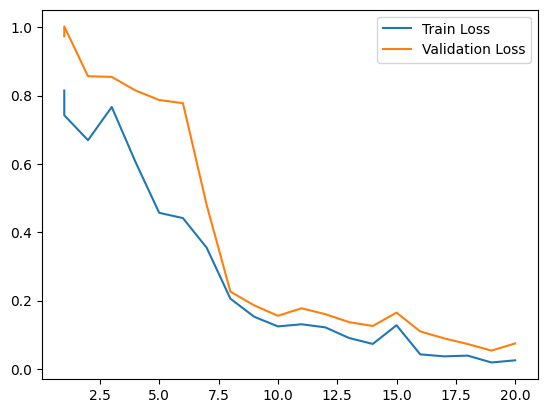

In [123]:
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.legend()

# ax = plt.gca()
# ax.set_ylim([1E-1, 1])

plt.show()

#### Recreating the model

In [ ]:
model_recreate = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

/tmp/ipykernel_4308/328531968.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


In [ ]:
# Optional: load best weights back into the model
if best_state is not None:
    model_recreate.load_state_dict(best_state)

In [ ]:
model

TimeSeriesViTRegressor(
  (spatial_encoder): SpatialCubeEncoder(
    (token_proj): Linear(in_features=5, out_features=128, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (temporal_proj): Linear(in_features=6, out_features=128, 

# Load model in from .pt

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)

In [ ]:
model_recreate.load_state_dict(checkpoint["model_state_dict"])
model_recreate.eval()

In [ ]:
cfg = checkpoint["config"]

model_recreate = TimeSeriesViTRegressor(
    cube_channels=cfg["CUBE_CHANNELS"],
    emb_dim=cfg["E"],
    grid_h=cfg["GRID_H"],
    grid_w=cfg["GRID_W"],
    seq_len=cfg["WINDOW"],
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0.1,
).to(DEVICE)

/tmp/ipykernel_28444/4055795266.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


# Predict on validation dataset

In [124]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch_cubes, batch_embs, batch_y, batch_weights in val_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        all_preds.append(outputs.cpu())
        all_targets.append(batch_y.cpu())

# Concatenate all batches
preds = torch.cat(all_preds, dim=0)
y = torch.cat(all_targets, dim=0)

In [126]:
# Unnormalize
preds_unnorm = preds * y_std + y_mean
y_unnorm = y * y_std + y_mean

# print("Predictions:", preds_unnorm)
# print("Targets:    ", y_unnorm)

print(preds_unnorm.mean(), preds_unnorm.std())
print(y_unnorm.mean(), y_unnorm.std())

# Plot
x_plot = np.linspace(250, 350, 100)
y_plot = x_plot

tensor(289.4006) tensor(11.8533)
tensor(289.6311) tensor(11.6653)


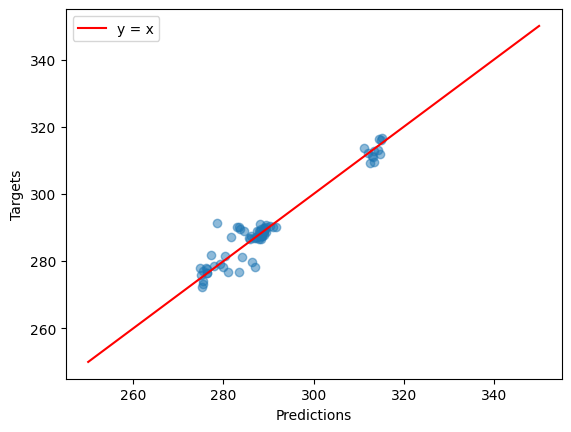

In [127]:
plt.scatter(preds_unnorm.numpy(), y_unnorm.numpy(), alpha=0.5)
plt.plot(x_plot, y_plot, label='y = x', color='red')
plt.xlabel("Predictions")
plt.ylabel("Targets")
plt.legend()
plt.show()

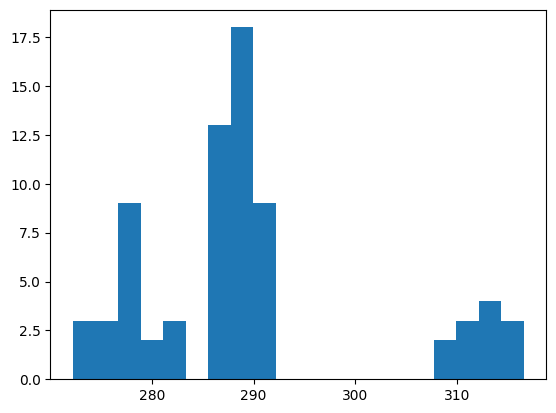

In [132]:
plt.hist(y_unnorm.numpy(), bins=20)
plt.show()

## Manual

In [ ]:
start = 100

In [ ]:
manual_batch_cubes = X_cubes_read[start:start+BATCH_SIZE]
manual_batch_embs = X_embs_read[start:start+BATCH_SIZE]
manual_y = y_read[start:start+BATCH_SIZE]

In [ ]:
manual_batch_cubes = manual_batch_cubes.copy()
manual_batch_embs = manual_batch_embs.copy()
manual_y = manual_y.copy()

In [ ]:
manual_batch_cubes = np.array(manual_batch_cubes)
manual_batch_embs = np.array(manual_batch_embs)
manual_y = np.array(manual_y)

In [ ]:
manual_batch_cubes = torch.from_numpy(manual_batch_cubes).to(DEVICE)
manual_batch_embs = torch.from_numpy(manual_batch_embs).to(DEVICE)
manual_y = torch.from_numpy(manual_y).to(DEVICE)

In [ ]:
manual_batch_cubes[0]

tensor([[[[0.0685, 0.0552, 0.0619, 0.0817, 0.0970],
          [0.0751, 0.0552, 0.0795, 0.1035, 0.1230],
          [0.0750, 0.0662, 0.0751, 0.0860, 0.0970],
          [0.0684, 0.0552, 0.0596, 0.0729, 0.0707],
          [0.0750, 0.0662, 0.0618, 0.0772, 0.0640]],

         [[0.0912, 0.0668, 0.0790, 0.1034, 0.1277],
          [0.0993, 0.0749, 0.1115, 0.1398, 0.1841],
          [0.1034, 0.0952, 0.0993, 0.1155, 0.1277],
          [0.0912, 0.0749, 0.0831, 0.0993, 0.0912],
          [0.0993, 0.0790, 0.0749, 0.0912, 0.0749]],

         [[0.1063, 0.0783, 0.0923, 0.1203, 0.1436],
          [0.1110, 0.0923, 0.1296, 0.1669, 0.2179],
          [0.1250, 0.1110, 0.1203, 0.1436, 0.1622],
          [0.1063, 0.0969, 0.1063, 0.1250, 0.1156],
          [0.1622, 0.1203, 0.0969, 0.1110, 0.0876]],

         [[0.1151, 0.0772, 0.1025, 0.1277, 0.1593],
          [0.1309, 0.1120, 0.1625, 0.1688, 0.2161],
          [0.1372, 0.1056, 0.1246, 0.1467, 0.1814],
          [0.1277, 0.0993, 0.1088, 0.1593, 0.1120],
      

In [ ]:
manual_y

tensor([291.0803, 300.2098, 305.7470, 303.7167, 292.9089, 290.1437, 288.3766,
        294.0676], device='cuda:0')

In [ ]:
manual_batch_cubes.shape

torch.Size([8, 300, 5, 5, 5])

In [ ]:
with torch.no_grad():
    # output_current = model(batch_cubes, batch_embs)
    output_best = model_recreate(manual_batch_cubes, manual_batch_embs)

In [ ]:
# print("Predictions:", output_current)
print("Predictions (best):", output_best)
print("Targets:    ", manual_y)

Predictions (best): tensor([297.3673, 297.3655, 297.3645, 297.3655, 297.3637, 297.3636, 297.3629,
        297.3634], device='cuda:0')
Targets:     tensor([291.0803, 300.2098, 305.7470, 303.7167, 292.9089, 290.1437, 288.3766,
        294.0676], device='cuda:0')


# Shap Analysis

In [ ]:
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        B = x.shape[0]

        cube_size = WINDOW * 5 * 5 * 5
        emb_size = WINDOW * E

        x_cube = x[:, :cube_size]
        x_emb = x[:, cube_size:cube_size + emb_size]

        x_cube = x_cube.view(B, WINDOW, 5, 5, 5)
        x_emb = x_emb.view(B, WINDOW, E)

        out = self.model(x_cube, x_emb)

        return out.unsqueeze(-1)  # ✅ FIX

In [ ]:
# Take small subset for SHAP (important for speed)
background_size = 10
test_size = 5

def flatten_inputs(x_cube, x_emb):
    return torch.cat([
        x_cube.reshape(x_cube.size(0), -1),
        x_emb.reshape(x_emb.size(0), -1)
    ], dim=1)

# Get data
bg_cubes, bg_embs, _ = next(iter(train_loader))
test_cubes, test_embs, test_y = next(iter(val_loader))

bg_cubes = bg_cubes[:background_size]
bg_embs = bg_embs[:background_size]

test_cubes = test_cubes[:test_size]
test_embs = test_embs[:test_size]

background = flatten_inputs(bg_cubes, bg_embs)
test_data = flatten_inputs(test_cubes, test_embs)

In [ ]:
wrapped_model = WrappedModel(model).to(DEVICE)
wrapped_model.eval()

explainer = shap.GradientExplainer(wrapped_model, background)

In [ ]:
shap_values = explainer(test_data)
shap_values = shap_values.values  # safer API

# Convert to numpy
shap_values = shap_values[0]  # regression output
shap_values = shap_values.reshape(test_size, -1)

OutOfMemoryError: CUDA out of memory. Tried to allocate 762.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 627.81 MiB is free. Including non-PyTorch memory, this process has 13.95 GiB memory in use. Of the allocated memory 13.71 GiB is allocated by PyTorch, and 101.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Sample sizes
BACKGROUND_SIZE = 200
EXPLAIN_SIZE = 500

# Sample indices from your train/val index arrays
background_sample_idx = np.random.choice(train_idx, BACKGROUND_SIZE, replace=False)
explain_sample_idx    = np.random.choice(val_idx, EXPLAIN_SIZE, replace=False)

# Function to load memmap samples and convert to torch (permute for ConvLSTM)
def load_memmap_batch(memmap_X, sample_indices, device):
    batch = memmap_X[sample_indices]  # shape: (B,T,H,W,C)
    batch = torch.tensor(batch, dtype=torch.float32, device=device)
    batch = batch.permute(0, 1, 4, 2, 3)  # (B,T,C,H,W)
    return batch

# Load SHAP background and explanation sets
X_background = load_memmap_batch(X, background_sample_idx, device)
X_explain    = load_memmap_batch(X, explain_sample_idx, device)

print(X_background.shape, X_explain.shape)

torch.Size([200, 50, 5, 5, 5]) torch.Size([500, 50, 5, 5, 5])


In [ ]:
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # original output: (B,)
        out = self.model(x)
        # add extra dimension: (B,) → (B,1)
        return out.unsqueeze(1)

In [ ]:
wrapped_model = ModelWrapper(model)
wrapped_model.eval()

ModelWrapper(
  (model): ConvLSTMModel(
    (cell): ConvLSTMCell(
      (conv): Conv2d(21, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (pool): AdaptiveAvgPool2d(output_size=(1, 1))
    (fc): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [ ]:
explainer = shap.DeepExplainer(wrapped_model, X_background)

AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 2.2678581564630784 - Tolerance: 0.01

In [ ]:
shap_values = explainer.shap_values(X_explain, check_additivity=False)

In [ ]:
X_background.shape

torch.Size([200, 50, 5, 5, 5])

In [ ]:
X_explain.shape

torch.Size([500, 50, 5, 5, 5])

In [ ]:
shap_values.shape

(500, 50, 5, 5, 5, 1)

In [ ]:
shap_vals = shap_values[..., 0]

In [ ]:
feature_importance = np.mean(np.abs(shap_vals), axis=(0,1,2,3))

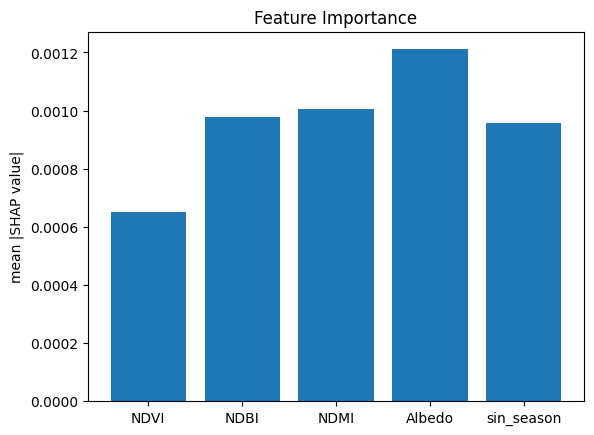

In [ ]:
feature_names = ["NDVI",	"NDBI",	"NDMI",	"Albedo",	"sin_season"]

plt.bar(feature_names, feature_importance)
plt.ylabel("mean |SHAP value|")
plt.title("Feature Importance")
plt.show()

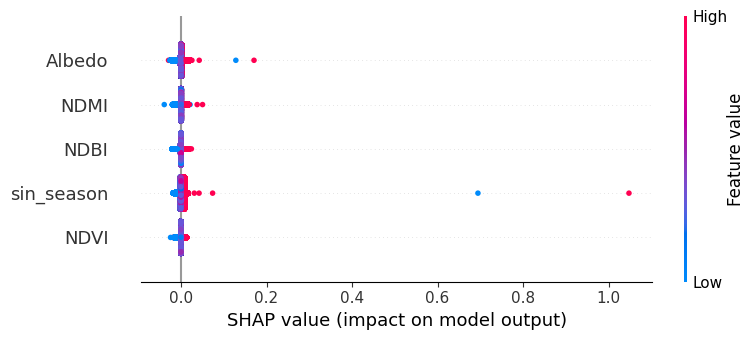

In [ ]:
X_flat = X_explain.reshape(-1, 5)
shap_flat = shap_vals.reshape(-1, 5)
shap.summary_plot(shap_flat, X_flat, feature_names=feature_names)

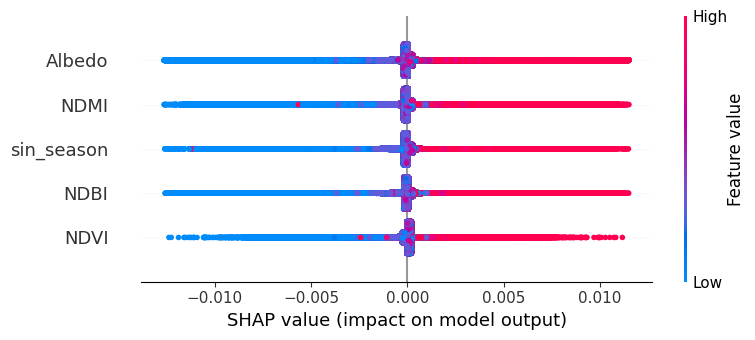

In [ ]:
low = np.percentile(shap_flat, 1)
high = np.percentile(shap_flat, 99)

mask = (shap_flat >= low) & (shap_flat <= high)

# keep rows where all features are within bounds
row_mask = mask.all(axis=1)

shap_filtered = shap_flat[row_mask]
X_filtered = X_flat[row_mask]

shap.summary_plot(shap_filtered, X_filtered, feature_names=feature_names)

# Pull in Green Loop Data

In [ ]:
export_new_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_landsat.csv')

In [ ]:
export_new_df

,point_id,mission,time,Blue,Red,NIR,SWIR1,SWIR2,LST_K
0,240,L4,1982-11-19 17:36:28,0.111658,0.120347,0.110805,0.079702,0.056575,280.665548
1,288,L4,1982-11-19 17:36:28,0.174220,0.207632,0.206780,0.206697,0.182030,281.209014
2,290,L4,1982-11-19 17:36:28,0.139927,0.167015,0.172570,0.156812,0.135830,280.665548
3,311,L4,1982-11-19 17:36:28,0.186622,0.224985,0.227268,0.197622,0.175430,280.665548
4,350,L4,1982-11-19 17:36:28,0.143062,0.178620,0.193112,0.143228,0.116002,281.752479
...,...,...,...,...,...,...,...,...,...
5628727,6936,L9,2026-01-12 18:08:31,0.024922,0.035647,0.052642,0.053825,0.038205,274.424244
5628728,6937,L9,2026-01-12 18:08:31,0.031055,0.047610,0.057125,0.040460,0.035290,275.466740
5628729,6938,L9,2026-01-12 18:08:31,0.039800,0.072580,0.071508,0.065155,0.058665,276.522908
5628730,6939,L9,2026-01-12 18:08:31,0.059682,0.104177,0.121502,0.164237,0.117130,277.271455


In [ ]:
b = export_new_df['Blue']
r = export_new_df['Red']
nir = export_new_df['NIR']
swir1 = export_new_df['SWIR1']
swir2 = export_new_df['SWIR2']
lst_k = export_new_df['LST_K']

columns = ['point_id','time']
export_clean_df = export_new_df[columns]

export_clean_df['LST_C'] = lst_k - 273.15
export_clean_df['NDVI'] = (nir - r) / (nir + r)
export_clean_df['NDBI'] = (swir1 - nir) / (swir1 + nir)
export_clean_df['NDMI'] = (nir - swir1) / (nir + swir1)
export_clean_df['Albedo'] = ((0.356*b)+(0.130*r)+(0.373*nir)+(0.085*swir1)+(0.072*swir2)- 0.018)/ 1.016

/tmp/ipython-input-1499989114.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_clean_df['LST_C'] = lst_k - 273.15
/tmp/ipython-input-1499989114.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_clean_df['NDVI'] = (nir - r) / (nir + r)
/tmp/ipython-input-1499989114.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

In [ ]:
most_recent_mask = export_clean_df['time'] == "2026-01-12 18:08:31"
most_recent_data = export_clean_df[most_recent_mask]

In [ ]:
most_recent_data.columns

Index(['point_id', 'time', 'LST_C', 'NDVI', 'NDBI', 'NDMI', 'Albedo'], dtype='object')

In [ ]:
print(most_recent_data['NDVI'].max())   # want higher
print(most_recent_data['NDMI'].max())   # want higher
print(most_recent_data['Albedo'].max()) # want higher
print(most_recent_data['NDBI'].min())   # want lower

0.6431295217697915
0.615355734935234
0.5626349138779526
-0.615355734935234


In [ ]:
target_NDVI   = 0.6431295217697915
target_NDBI   = 0.615355734935234
target_NDMI   = 0.5626349138779526
target_Albedo = -0.615355734935234

In [ ]:
most_recent_data["NDVI_change"]   = target_NDVI   - most_recent_data["NDVI"]
most_recent_data["NDBI_change"]   = target_NDBI   - most_recent_data["NDBI"]
most_recent_data["NDMI_change"]   = target_NDMI   - most_recent_data["NDMI"]
most_recent_data["Albedo_change"] = target_Albedo - most_recent_data["Albedo"]

/tmp/ipython-input-2345914459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data["NDVI_change"]   = target_NDVI   - most_recent_data["NDVI"]
/tmp/ipython-input-2345914459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data["NDBI_change"]   = target_NDBI   - most_recent_data["NDBI"]
/tmp/ipython-input-2345914459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [ ]:
most_recent_data

,point_id,time,LST_C,NDVI,NDBI,NDMI,Albedo,NDVI_change,NDBI_change,NDMI_change,Albedo_change
5622170,0,2026-01-12 18:08:31,5.081918,0.332616,-0.065700,0.065700,0.069441,0.310514,0.681055,0.496935,-0.684797
5622171,1,2026-01-12 18:08:31,5.102426,0.327418,-0.132436,0.132436,0.096431,0.315711,0.747792,0.430199,-0.711787
5622172,2,2026-01-12 18:08:31,5.157115,0.378909,-0.164664,0.164664,0.077078,0.264220,0.780019,0.397971,-0.692434
5622173,3,2026-01-12 18:08:31,5.174205,0.404057,-0.101426,0.101426,0.100100,0.239072,0.716782,0.461209,-0.715456
5622174,4,2026-01-12 18:08:31,4.993050,0.315563,-0.027398,0.027398,0.117658,0.327566,0.642754,0.535237,-0.733014
...,...,...,...,...,...,...,...,...,...,...,...
5628727,6936,2026-01-12 18:08:31,1.274244,0.192491,0.011107,-0.011107,0.022114,0.450639,0.604249,0.573742,-0.637470
5628728,6937,2026-01-12 18:08:31,2.316740,0.090848,-0.170774,0.170774,0.026115,0.552281,0.786130,0.391861,-0.641470
5628729,6938,2026-01-12 18:08:31,3.372908,-0.007443,-0.046483,0.046483,0.041377,0.650573,0.661839,0.516152,-0.656732
5628730,6939,2026-01-12 18:08:31,4.121455,0.076768,0.149559,-0.149559,0.083173,0.566362,0.465797,0.712194,-0.698529


In [ ]:
ten_years_seconds = 315360000

In [ ]:
print(df['delta_time'].min())
print(df['delta_time'].max())
print(df['delta_time'].mean())

-756682739.0
1289089810.0
376003734.6639071


In [ ]:
most_recent_data['time_change'] = 315360000

/tmp/ipython-input-2792004285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_data['time_change'] = 315360000


In [ ]:
most_recent_data.columns

Index(['point_id', 'time', 'LST_C', 'NDVI', 'NDBI', 'NDMI', 'Albedo',
       'NDVI_change', 'NDBI_change', 'NDMI_change', 'Albedo_change',
       'time_change'],
      dtype='object')

In [ ]:
columns_predict = ['point_id', 'time_change', 'NDVI_change', 'NDBI_change', 'NDMI_change', 'Albedo_change']
most_recent_predict = most_recent_data[columns_predict]

In [ ]:
most_recent_predict

,point_id,time_change,NDVI_change,NDBI_change,NDMI_change,Albedo_change
5622170,0,315360000,0.310514,0.681055,0.496935,-0.684797
5622171,1,315360000,0.315711,0.747792,0.430199,-0.711787
5622172,2,315360000,0.264220,0.780019,0.397971,-0.692434
5622173,3,315360000,0.239072,0.716782,0.461209,-0.715456
5622174,4,315360000,0.327566,0.642754,0.535237,-0.733014
...,...,...,...,...,...,...
5628727,6936,315360000,0.450639,0.604249,0.573742,-0.637470
5628728,6937,315360000,0.552281,0.786130,0.391861,-0.641470
5628729,6938,315360000,0.650573,0.661839,0.516152,-0.656732
5628730,6939,315360000,0.566362,0.465797,0.712194,-0.698529


In [ ]:
points_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_points.csv')

In [ ]:
points_df['point_id'] = points_df.index

In [ ]:
points_df

,long,lat,distance,point_id
0,-111.917514,40.750953,326.310297,0
1,-111.917512,40.750682,315.709676,1
2,-111.917511,40.750412,307.679686,2
3,-111.917509,40.750142,302.425162,3
4,-111.917507,40.749872,300.091933,4
...,...,...,...,...
6936,-111.892401,40.769679,207.667444,6936
6937,-111.892399,40.769409,237.666757,6937
6938,-111.892398,40.769139,267.666071,6938
6939,-111.892396,40.768869,297.665384,6939
